In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

np.random.seed(42)

In [ ]:
# Сначала создаем с правильными типами
df = pd.DataFrame({
    'User_ID': range(1, 201),
    'Group': np.random.choice(['A', 'B'], size=200),
    'Signup_Date': np.random.choice([
        '2024-01-15', '05.02.2024', '2024/03/10', 'not recorded', None
    ], size=200),
    'Age': np.random.normal(35, 10, 200).astype(int),
    'Spending': np.random.exponential(5000, 200).round(2),
    'Visits': np.random.poisson(5, 200),
    'Is_Active': np.random.choice([1, 0, 'yes', 'no', None], size=200)
})

# Эффект группы B
mask_b = df['Group'] == 'B'
df.loc[mask_b, 'Spending'] = df.loc[mask_b, 'Spending'] * 1.1

In [ ]:
# Превращаем колонки в object, чтобы можно было добавить строки
df['Age'] = df['Age'].astype(object)
df['Spending'] = df['Spending'].astype(object)
df['Visits'] = df['Visits'].astype(object)

# Теперь добавляем грязные данные
df.loc[10, 'Age'] = 'thirty'
df.loc[50, 'Spending'] = 'not_a_number'
df.loc[100, 'Age'] = None
df.loc[150, 'Spending'] = None
df.loc[5, 'Visits'] = 'many'
df.loc[20, 'Is_Active'] = None

In [ ]:
print("=== Грязные данные ===")
print(df.head(10))
print(f"\nРазмер: {df.shape}")
print(f"\nПропуски:\n{df.isnull().sum()}")
print(f"\nТипы:\n{df.dtypes}")

=== Грязные данные ===
   User_ID Group   Signup_Date Age   Spending Visits Is_Active
0        1     A    2024-01-15  39    4209.18      7         0
1        2     B  not recorded  52    360.899      7         0
2        3     A           NaN  28     187.58      7       yes
3        4     A  not recorded  18      718.5      3        no
4        5     A           NaN  41      68.83      7        no
5        6     B           NaN  20    430.925   many       yes
6        7     A    2024/03/10  23    5883.64      5         1
7        8     A           NaN  39    3821.57      5       yes
8        9     A  not recorded  33    6929.69      8      None
9       10     B           NaN  28  13440.647      4        no

Размер: (200, 7)

Пропуски:
User_ID         0
Group           0
Signup_Date    30
Age             1
Spending        1
Visits          0
Is_Active      37
dtype: int64

Типы:
User_ID         int64
Group             str
Signup_Date       str
Age            object
Spending       object

In [ ]:

def parse_date(x):
    if pd.isna(x):
        return pd.NaT
    x = str(x)

    formats = ['%Y-%m-%d', '%d.%m.%Y', '%Y/%m/%d']

    for fmt in formats:
        try:
            return pd.to_datetime(x, format=fmt)
        except(ValueError, TypeError):
            continue
    return pd.NaT



def clean_numeric(x):
    if pd.isna(x):
        return np.nan 
    x = str(x)
    x = pd.to_numeric(x, errors='coerce')
    return x 



def clean_active(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().lower()
    if x in ('1', 'yes'):
        return 1
    if x in ('0', 'no'):
        return 0
    return np.nan

def clean_dataframe(df, column_map):
    df = df.copy()
    for col, func in column_map.items():
        if col in df.columns:
            df[col] = df[col].apply(func)
    return df 


mapping = {
    'Spending' : clean_numeric,
    'Visits' : clean_numeric,
    'Signup_Date' : parse_date,
    'Age' : clean_numeric,
    'Is_Active' : clean_active
}


clean_df = clean_dataframe(df, mapping)
clean_df

,User_ID,Group,Signup_Date,Age,Spending,Visits,Is_Active
0,1,A,NaT,39.0,4209.180,7.0,0.0
1,2,B,NaT,52.0,360.899,7.0,0.0
2,3,A,NaT,28.0,187.580,7.0,1.0
3,4,A,NaT,18.0,718.500,3.0,0.0
4,5,A,NaT,41.0,68.830,7.0,0.0
...,...,...,...,...,...,...,...
195,196,B,NaT,34.0,14861.759,8.0,0.0
196,197,B,NaT,48.0,25864.993,5.0,1.0
197,198,B,NaT,28.0,1261.788,1.0,1.0
198,199,A,NaT,46.0,2383.960,3.0,NaN


In [ ]:
print('СРЕДНИЕ ТРАТЫ ПО ГРУППАМ')


avg_group = clean_df.groupby('Group')['Spending'].mean()
avg_group

СРЕДНИЕ ТРАТЫ ПО ГРУППАМ


Group
A    4698.896633
B    5651.457900
Name: Spending, dtype: float64

In [ ]:
print('КОНВЕРСИЯ ПО ГРУППАМ')


conv_group = clean_df.groupby('Group')['Is_Active'].mean()
conv_group

КОНВЕРСИЯ ПО ГРУППАМ


Group
A    0.506329
B    0.440476
Name: Is_Active, dtype: float64

ГРАФИКИ


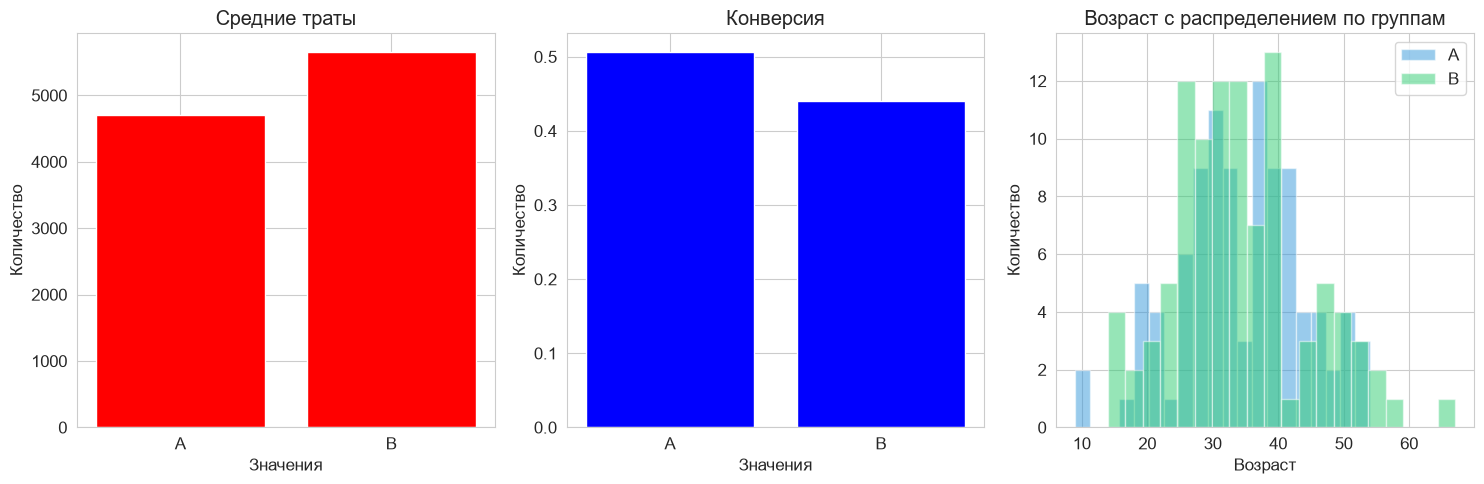

In [ ]:

print('ГРАФИКИ')

fig,axes = plt.subplots(1,3, figsize=(15,5))

axes[0].bar(avg_group.index, avg_group.values, color='red')
axes[0].set_title('Средние траты')
axes[0].set_xlabel('Значения')
axes[0].set_ylabel('Количество')

axes[1].bar(conv_group.index, conv_group.values, color='blue')
axes[1].set_title('Конверсия')
axes[1].set_xlabel('Значения')
axes[1].set_ylabel('Количество')

for group, color in zip(['A', 'B'], ['#3498db', '#2ecc71']):
    mask = clean_df['Group'] == group
    axes[2].hist(clean_df.loc[mask, 'Age'].dropna(), bins=20,
                color=color, alpha=0.5, label=group)
axes[2].set_title('Возраст с распределением по группам')
axes[2].set_xlabel('Возраст')
axes[2].set_ylabel('Количество')
axes[2].legend()


plt.tight_layout()
plt.show()